In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("dataset.csv")

data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
data.shape

(4000, 28)

In [4]:
data.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [6]:
data.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
data.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [10]:
data.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64

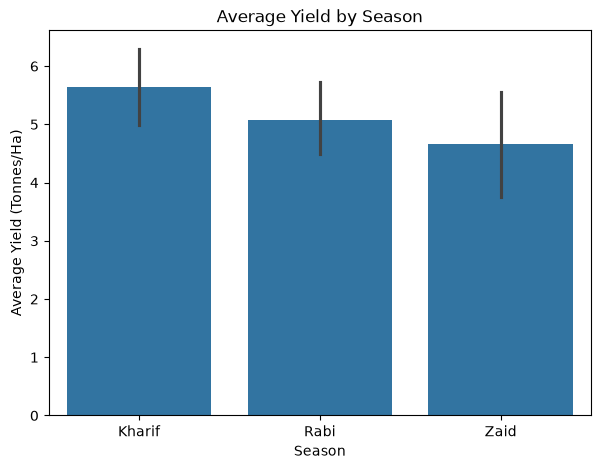

In [11]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Season",
    y="Yield_Tonnes_Ha",
    data=data
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

In [12]:
data.groupby("Season")["Production_Tonnes"].mean().sort_values(ascending=False)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

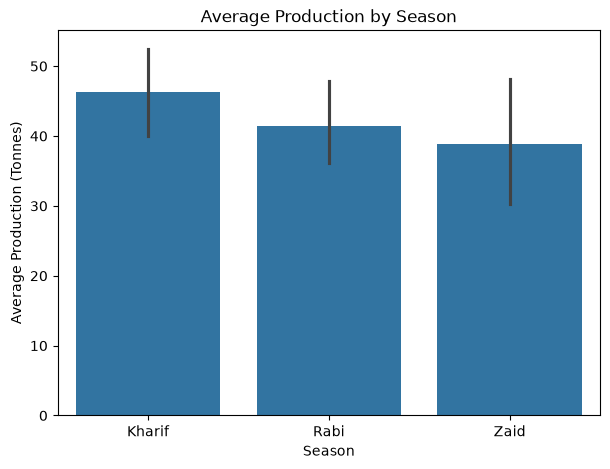

In [13]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Season",
    y="Production_Tonnes",
    data=data
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.show()

In [14]:
data.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

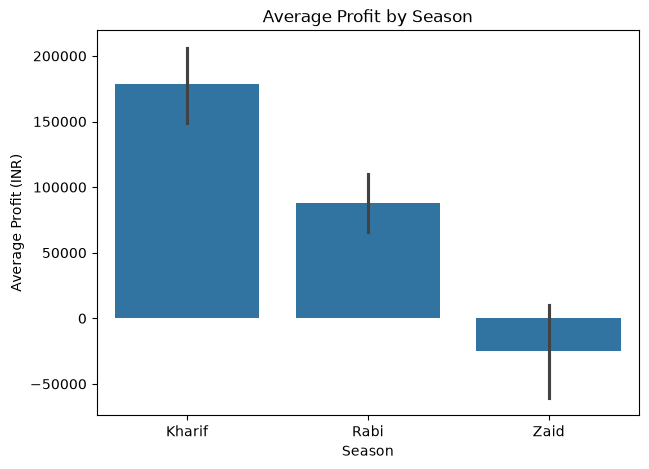

In [15]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Season",
    y="Profit_INR",
    data=data
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

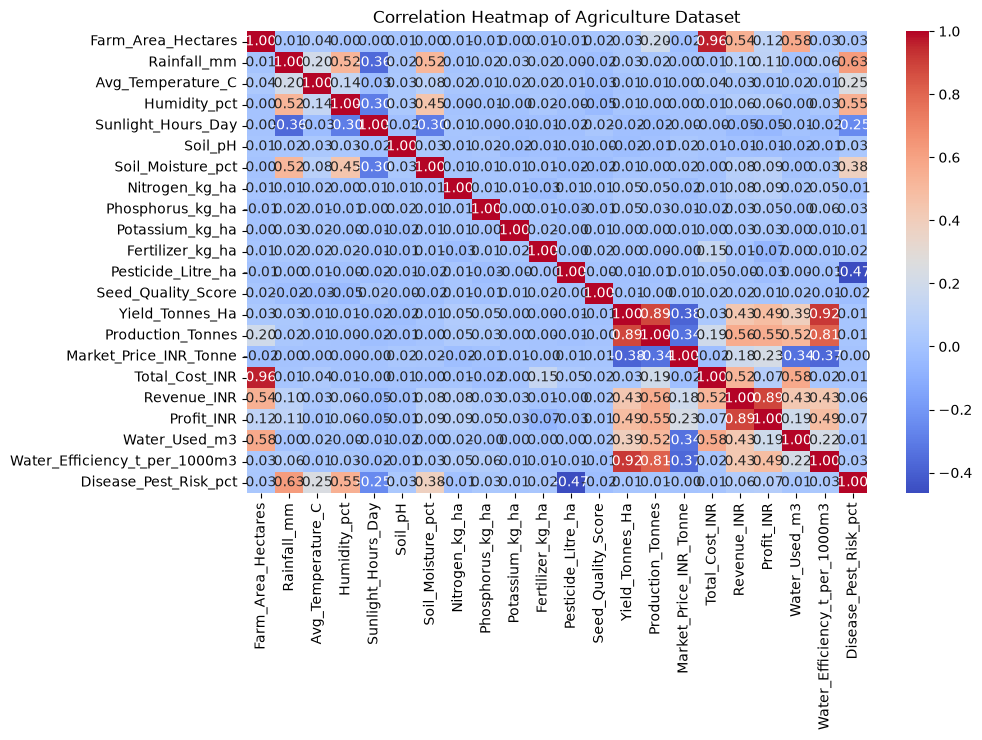

In [16]:
# Correlation analysis of numerical variables

plt.figure(figsize=(10, 6))

correlation = data.select_dtypes(include=np.number).corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Agriculture Dataset")
plt.show()

In [18]:
categorical_columns = data.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


C:\Users\Balaj\AppData\Local\Temp\ipykernel_324\2460073594.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include="object").columns.tolist()


Average Profit by Crop:
Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


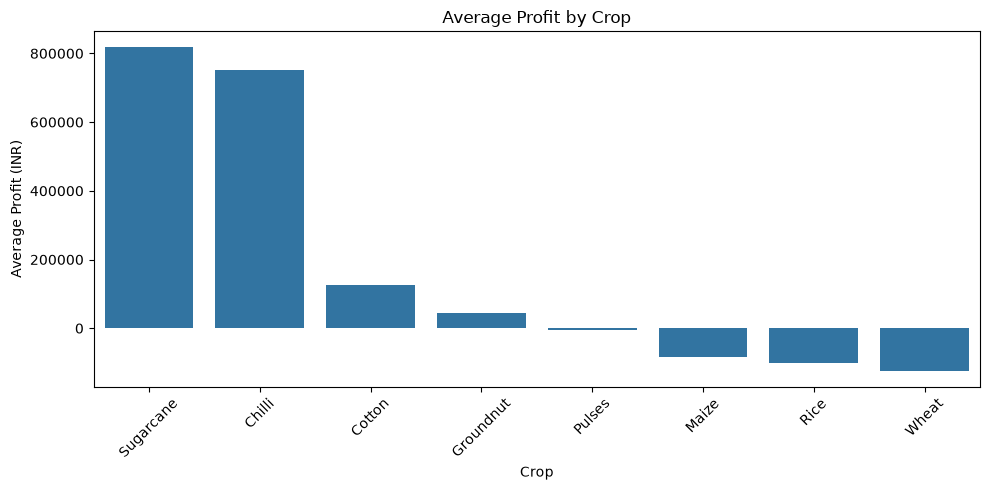

In [19]:
profit_by_crop = data.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

print("Average Profit by Crop:")
print(profit_by_crop)

plt.figure(figsize=(10, 5))
sns.barplot(x=profit_by_crop.index, y=profit_by_crop.values)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Profit by Irrigation Method:
Irrigation_Method
Drip         219625.997814
Sprinkler     91121.079019
Rainfed       79050.365034
Flood         73354.022901
Name: Profit_INR, dtype: float64


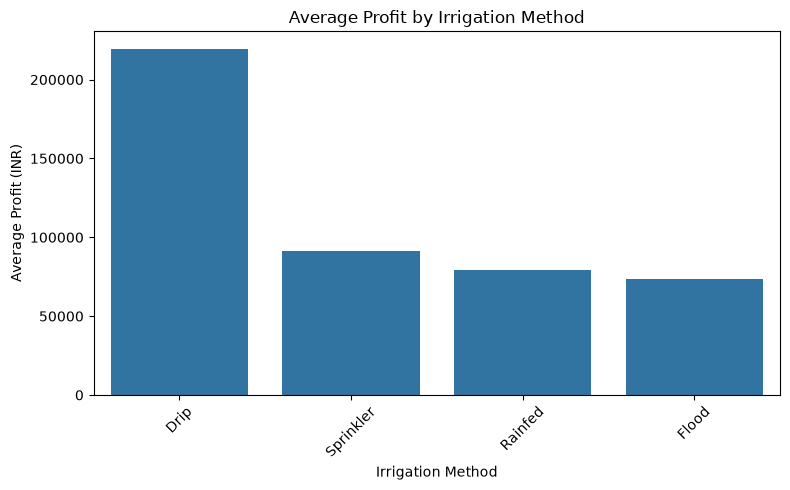

In [20]:
profit_by_irrigation = data.groupby("Irrigation_Method")["Profit_INR"].mean().sort_values(ascending=False)

print("Average Profit by Irrigation Method:")
print(profit_by_irrigation)

plt.figure(figsize=(8, 5))
sns.barplot(x=profit_by_irrigation.index, y=profit_by_irrigation.values)

plt.title("Average Profit by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Profit by State:
State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Profit_INR, dtype: float64


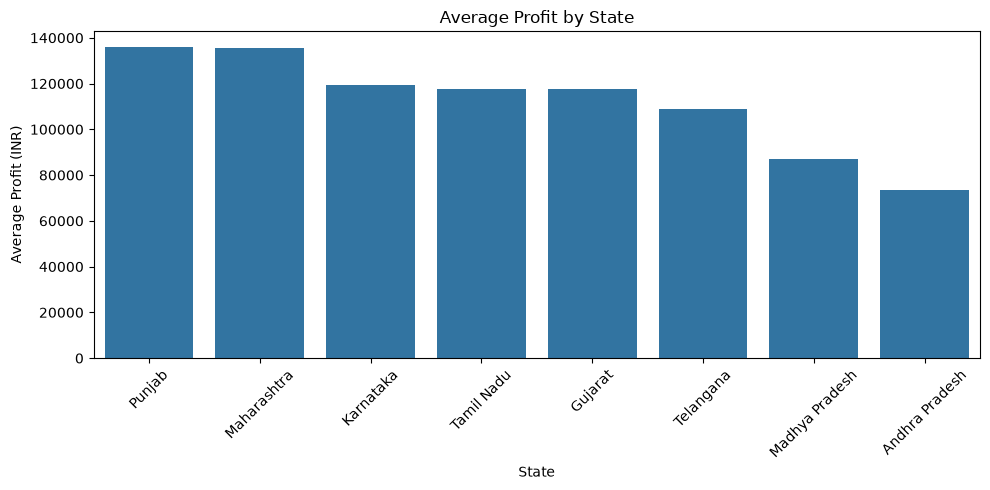

In [21]:
profit_by_state = data.groupby("State")["Profit_INR"].mean().sort_values(ascending=False)

print("Average Profit by State:")
print(profit_by_state)

plt.figure(figsize=(10, 5))
sns.barplot(x=profit_by_state.index, y=profit_by_state.values)

plt.title("Average Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Yield by Irrigation Method:
Irrigation_Method
Drip         6.620662
Sprinkler    5.188819
Flood        4.897724
Rainfed      4.613182
Name: Yield_Tonnes_Ha, dtype: float64


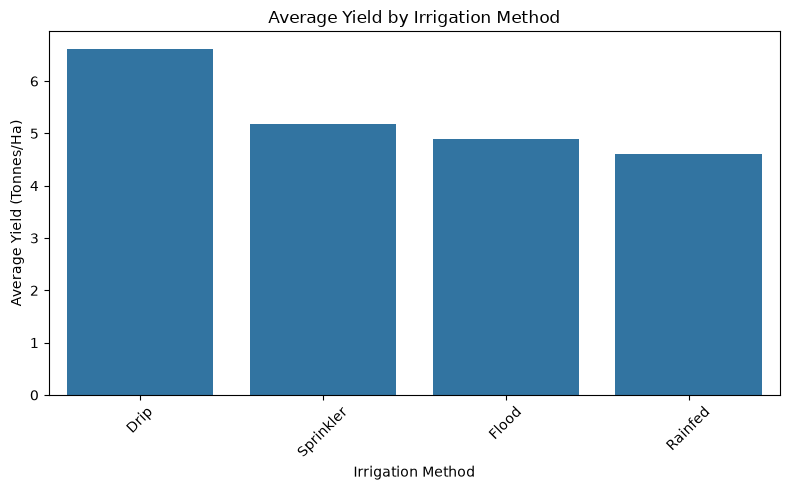

In [22]:
yield_by_irrigation = data.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Irrigation Method:")
print(yield_by_irrigation)

plt.figure(figsize=(8, 5))
sns.barplot(x=yield_by_irrigation.index, y=yield_by_irrigation.values)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Yield by Irrigation Method:
Irrigation_Method
Drip         6.620662
Sprinkler    5.188819
Flood        4.897724
Rainfed      4.613182
Name: Yield_Tonnes_Ha, dtype: float64


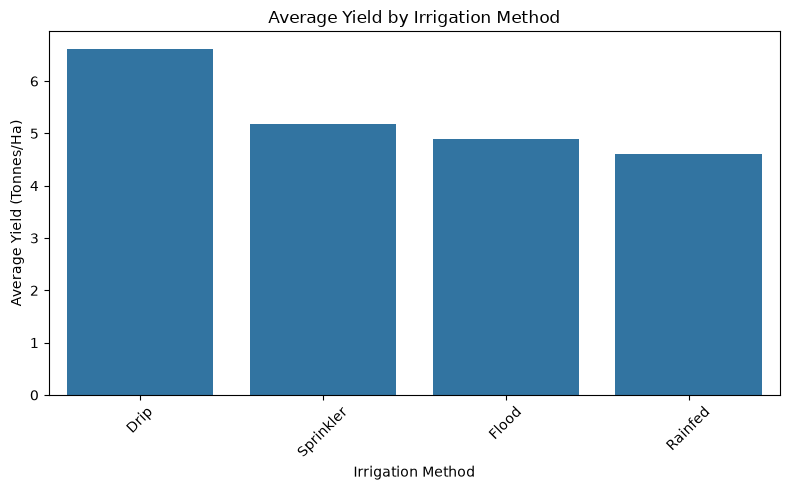

In [23]:
# Average Yield by Irrigation Method

yield_by_irrigation = data.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Irrigation Method:")
print(yield_by_irrigation)

plt.figure(figsize=(8, 5))
sns.barplot(x=yield_by_irrigation.index, y=yield_by_irrigation.values)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Yield by Season and Irrigation Method:
Irrigation_Method      Drip     Flood   Rainfed  Sprinkler
Season                                                    
Kharif             7.256296  5.000017  5.721193   4.671375
Rabi               6.208287  5.098904  3.939151   5.356609
Zaid               5.848143  4.031632  3.063786   6.172773


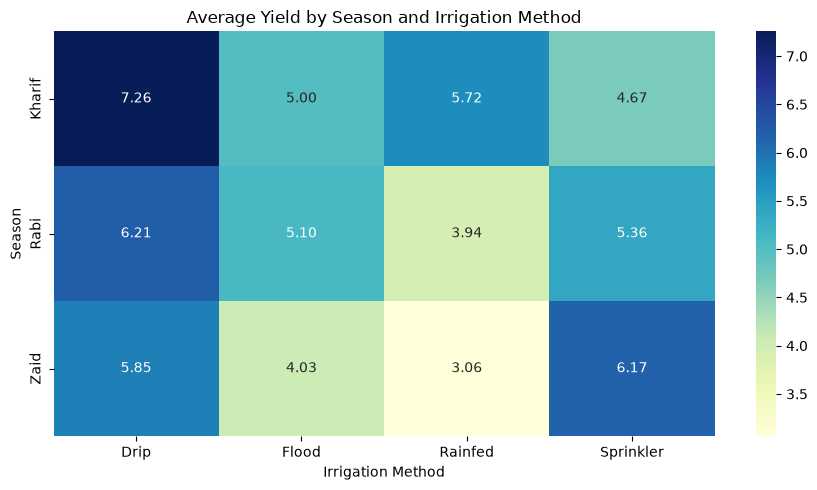

In [24]:
# Average Yield by Season and Irrigation Method

yield_season_irrigation = data.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Season",
    columns="Irrigation_Method",
    aggfunc="mean"
)

print("Average Yield by Season and Irrigation Method:")
print(yield_season_irrigation)

plt.figure(figsize=(9, 5))

sns.heatmap(
    yield_season_irrigation,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by Season and Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

Average Yield by Crop:
Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64


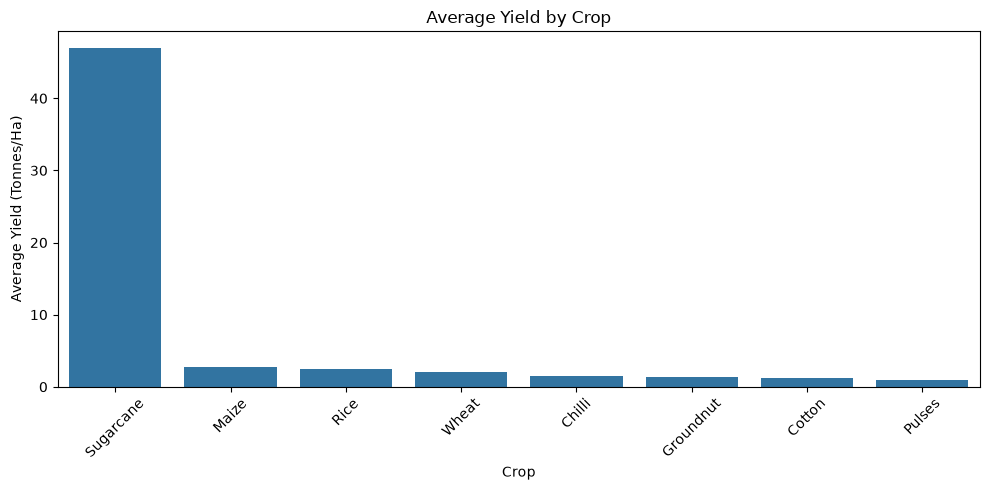

In [25]:
yield_by_crop = data.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Crop:")
print(yield_by_crop)

plt.figure(figsize=(10, 5))
sns.barplot(x=yield_by_crop.index, y=yield_by_crop.values)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Revenue by Crop:
Crop
Sugarcane    1.371980e+06
Chilli       1.276777e+06
Cotton       6.394231e+05
Groundnut    5.429355e+05
Pulses       5.284659e+05
Maize        4.570680e+05
Rice         4.236153e+05
Wheat        4.001049e+05
Name: Revenue_INR, dtype: float64


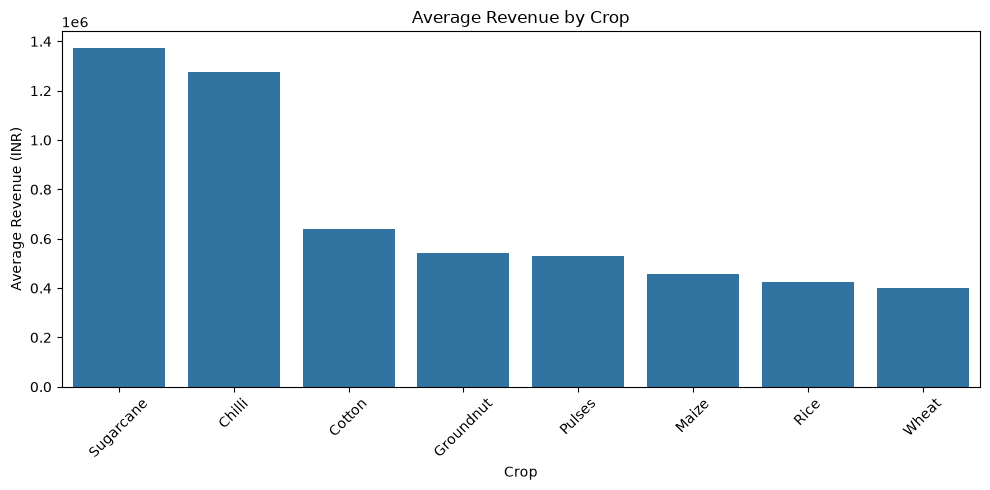

In [26]:
# Average Revenue by Crop

revenue_by_crop = data.groupby("Crop")["Revenue_INR"].mean().sort_values(ascending=False)

print("Average Revenue by Crop:")
print(revenue_by_crop)

plt.figure(figsize=(10, 5))
sns.barplot(x=revenue_by_crop.index, y=revenue_by_crop.values)

plt.title("Average Revenue by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Production by Irrigation Method:
Irrigation_Method
Drip         57.994284
Sprinkler    42.337629
Flood        38.731611
Rainfed      36.605034
Name: Production_Tonnes, dtype: float64


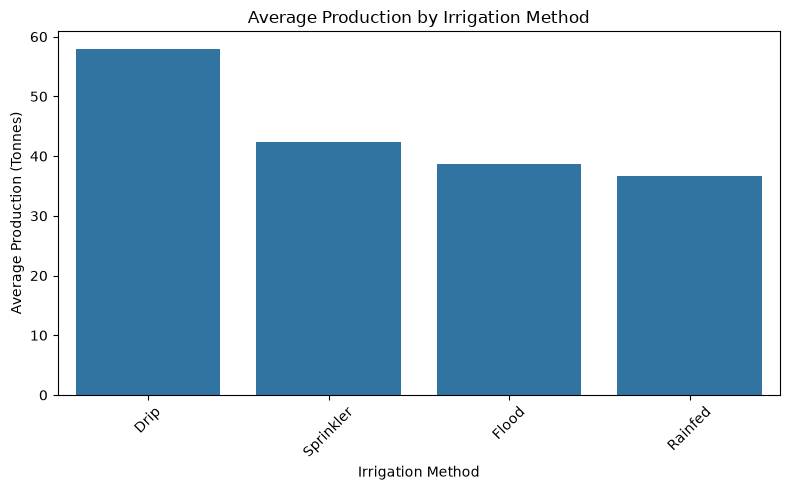

In [27]:
production_by_irrigation = data.groupby("Irrigation_Method")["Production_Tonnes"].mean().sort_values(ascending=False)

print("Average Production by Irrigation Method:")
print(production_by_irrigation)

plt.figure(figsize=(8, 5))
sns.barplot(x=production_by_irrigation.index, y=production_by_irrigation.values)

plt.title("Average Production by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Revenue by Irrigation Method:
Irrigation_Method
Drip         754571.233880
Sprinkler    617730.301090
Flood        610138.153435
Rainfed      584353.977906
Name: Revenue_INR, dtype: float64


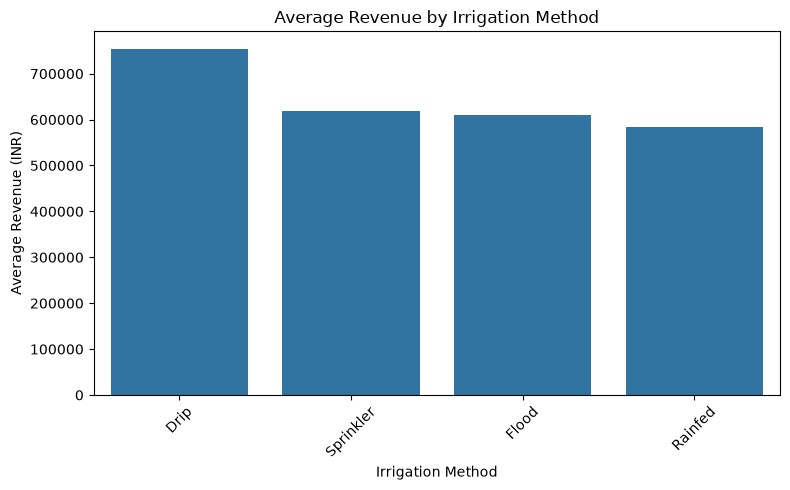

In [28]:
revenue_by_irrigation = data.groupby("Irrigation_Method")["Revenue_INR"].mean().sort_values(ascending=False)

print("Average Revenue by Irrigation Method:")
print(revenue_by_irrigation)

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_irrigation.index, y=revenue_by_irrigation.values)

plt.title("Average Revenue by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Profit Margin by Crop:
Crop
Chilli       33.776597
Sugarcane    27.346809
Cotton       -8.229093
Groundnut   -28.658537
Pulses      -36.484144
Maize       -81.539685
Wheat       -91.702553
Rice        -99.368087
Name: Profit_Margin_pct, dtype: float64


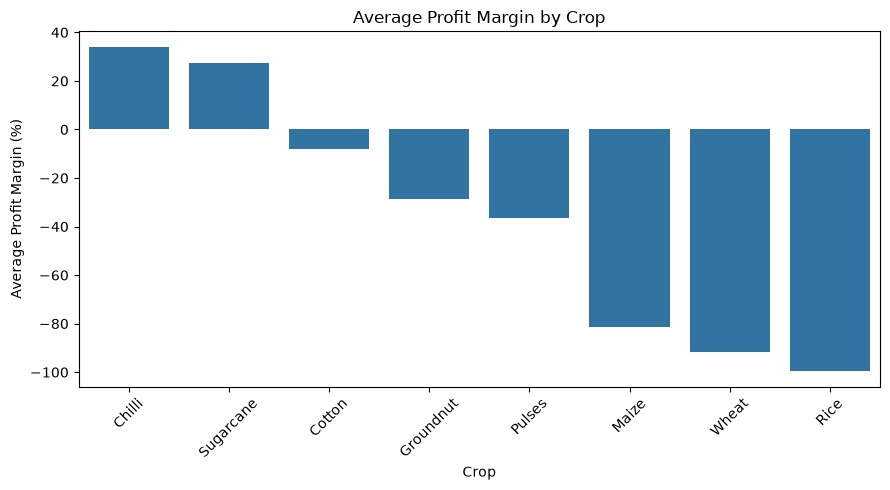

In [29]:
data["Profit_Margin_pct"] = (
    data["Profit_INR"] / data["Revenue_INR"]
) * 100

profit_margin_by_crop = (
    data.groupby("Crop")["Profit_Margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit Margin by Crop:")
print(profit_margin_by_crop)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=profit_margin_by_crop.index,
    y=profit_margin_by_crop.values
)

plt.title("Average Profit Margin by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

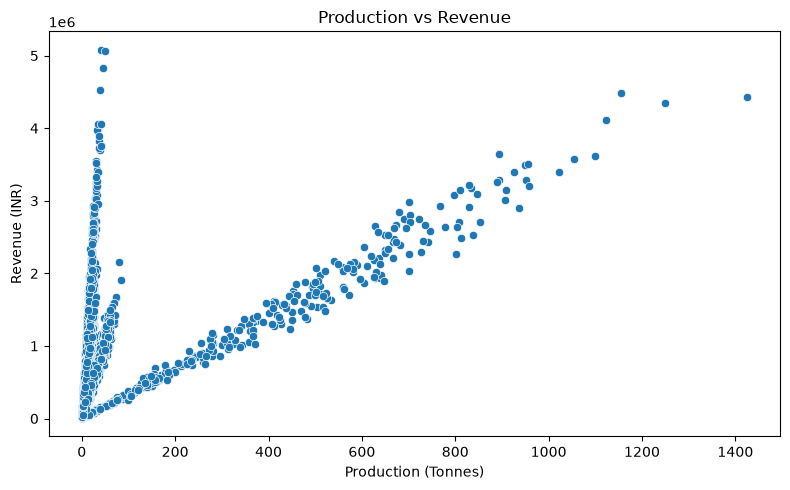

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Production_Tonnes",
    y="Revenue_INR",
    data=data
)

plt.title("Production vs Revenue")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Revenue (INR)")
plt.tight_layout()
plt.show()

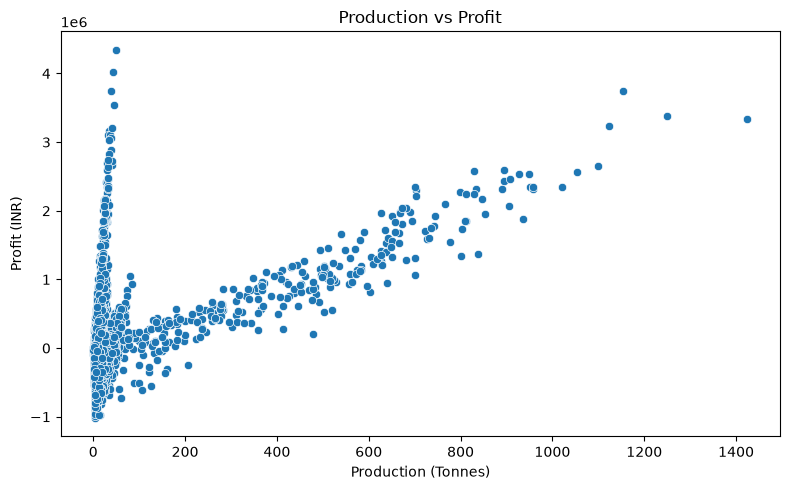

In [31]:
# Production vs Profit

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Production_Tonnes",
    y="Profit_INR",
    data=data
)

plt.title("Production vs Profit")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

In [32]:
profit_corr = data.select_dtypes(include="number").corr()["Profit_INR"].sort_values(
    ascending=False
)

print("Correlation with Profit:")
print(profit_corr)

Correlation with Profit:
Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.489822
Water_Efficiency_t_per_1000m3    0.489487
Profit_Margin_pct                0.481375
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.108104
Soil_Moisture_pct                0.091757
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Pro

Top 5 Crops by Average Profit:
Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Name: Profit_INR, dtype: float64


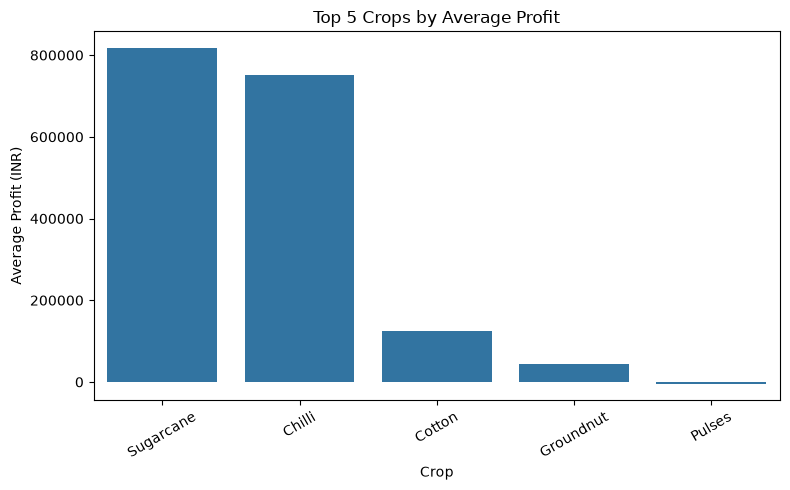

In [33]:
top_profit_crops = (
    data.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 Crops by Average Profit:")
print(top_profit_crops)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=top_profit_crops.index,
    y=top_profit_crops.values
)

plt.title("Top 5 Crops by Average Profit")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [36]:
print("\n1. Most Profitable Crop:")
print(data.groupby("Crop")["Profit_INR"].mean().idxmax())

print("\n2. Best Irrigation Method by Profit:")
print(data.groupby("Irrigation_Method")["Profit_INR"].mean().idxmax())

print("\n3. Best Season by Profit:")
print(data.groupby("Season")["Profit_INR"].mean().idxmax())

print("\n4. Best State by Profit:")
print(data.groupby("State")["Profit_INR"].mean().idxmax())

print("\n5. Strongest Numerical Factor Related to Profit:")
print(profit_corr.drop("Profit_INR").idxmax())

print("\n6. Strongest Correlation with Profit:")
print(round(profit_corr.drop("Profit_INR").max(), 3))


1. Most Profitable Crop:
Sugarcane

2. Best Irrigation Method by Profit:
Drip

3. Best Season by Profit:
Kharif

4. Best State by Profit:
Punjab

5. Strongest Numerical Factor Related to Profit:
Revenue_INR

6. Strongest Correlation with Profit:
0.887
